# COGS 108 - EDA Checkpoint

## Authors
- Jing Wang: Conceptualization, Project administration, EDA framework design, Interpretation, Writing – review & editing, Final integration.
- Qifeng Shen: Data curation, Software, Data wrangling, Missingness analysis, Outlier treatment, Writing – original draft (Data cleaning section).
- Ivy Wu: Analysis, Visualization, Exploratory data analysis (univariate & bivariate), Software.
- Yuqian Gao: Analysis, Methodology, Statistical exploration, Correlation analysis, Modeling rationale, Writing – original draft (Analysis logic section).
- Alina Gao: Ethics & Privacy (updated), Bias analysis in EDA, Societal context interpretation, Writing – original draft (Ethics & Interpretation sections), Writing – review & editing.


# Research Question

What listing characteristics are associated with nightly prices of Airbnb rentals in San Diego?
- Using publicly available Airbnb listing data, we examine how capacity (accommodates/bedrooms/bathrooms), property type/room type, neighborhood or zip code, review ratings, minimum nights, and availability relate to nightly price. We estimate these associations using multiple regression (e.g., log(price)) while controlling for host experience (host listings count/superhot status), amenity indicators (Wi-Fi, parking, pool, kitchen, AC), booking policies (instant book, cancellation policy), and time-related factors (month/season) when available.


## Background and Prior Work

Airbnb has become a major platform in the short-term rental market and plays an important role in tourism and local housing economies. Nightly pricing is a key factor that affects both hosts and guests, as it influences host revenue and guest booking decisions. However, Airbnb prices are not set randomly and are often related to various listing characteristics.
Prior research has examined determinants of Airbnb pricing using publicly available listing data. For example, Wang and Nicolau (2017) found that location, property type, and review ratings significantly influence nightly prices. Similarly, Gunter (2018) showed that listings offering entire homes, larger accommodation capacity, and higher guest ratings tend to command higher prices. These studies suggest that observable characteristics such as neighborhood, property size, availability, and user-generated reviews are important predictors of rental pricing. While prior studies have examined European or multi-country markets, fewer studies focus specifically on San Diego, which motivates our city-level analysis
Building on this prior work, our project focuses on modeling Airbnb rental prices in San Diego. Specifically, we examine how listing characteristics such as location (e.g., zip code), property type (entire home vs. private room), accommodation capacity, availability, and guest review ratings jointly relate to nightly prices. We apply exploratory data analysis and regression-based modeling to estimate the relative importance of these features.
At the same time, we acknowledge that our dataset is observational and may omit unobserved factors, such as host experience, interior design quality, off-platform negotiations, or seasonal events (e.g., conventions or tourism peaks) that could also affect pricing. Therefore, our results should be interpreted as associations rather than causal effects. Our city-level analysis allows us to examine pricing patterns within a single metropolitan area while contributing to the broader literature on short-term rental pricing.

### References
- Wang, D., & Nicolau, J. L. (2017). Price determinants of sharing economy-based accommodation rental: A study of Airbnb listings. International Journal of Hospitality Management, 62, 120–131.
- Gunter, U. (2018). What makes an Airbnb listing attractive? Evidence from Europe. Tourism Economics, 24(2), 210–225.


# Hypothesis


We hypothesize that Airbnb rental prices in San Diego are associated with several characteristics, including location, size, and available services or amenities. Listings located closer to scenic areas such as the coast or forests, or city centers, are expected to be associated with higher nightly prices. These locations typically offer greater convenience and a more desirable stay experience. In addition, larger listings and those offering more amenities or higher quality service, such as pet-friendly options, may be associated with higher prices due to higher maintenance costs.

Our analysis plan begins with exploratory data analysis (EDA) to examine the distributions of rental prices and the above listing characteristics. We will use visualizations to explore how prices vary across different locations and feature categories and then apply regression models to assess the associations between rental prices and these characteristics while controlling for other relevant variables. Throughout the analysis, we will clearly state assumptions and discuss potential limitations, such as unobserved factors like:

Interior design and quality: Listings that are well-decorated or recently renovated may command higher prices, even when their square footage is similar to other listings.

Host communication style: Hosts who respond quickly and are polite and patient with guests may increase perceived value and allow hosts to charge higher prices.

Off-platform negotiations: Some hosts may offer discounts or special rates outside of Airbnb's platform, meaning the actual transaction price may differ from the listed price in our dataset.

Subjective perceptions of neighborhood safety: Guests’ perceptions of safety may influence willingness to pay.

Proximity to major seasonal events: Large events in San Diego, such as Comic-Con, the San Diego Marathon, and the MLB season, may temporarily raise local demand and rental prices in ways that are not fully reflected in broad time variables.

## Data


### Data overview

To examine which listing characteristics are associated with Airbnb nightly prices in San Diego, we use two complementary datasets:
(1) Listing-level Airbnb dataset containing property, host, and review-related attributes.
(2) County-level socioeconomic indicator from the U.S. Census Bureau (ACS) providing broader economic context.

---

#### Dataset #1: Airbnb Listings Data (San Diego)

**Dataset name:** Airbnb Listings Data (San Diego)  

**Source:** `data/00-raw/listings.csv` (public Airbnb listing data)

**Unit of analysis:** One row = one Airbnb listing; one column = one listing-level attribute (tidy format)  

**Size:** 13,162 listings × 18 variables (raw data)

**Primary outcome variable:** `nightly_price` (USD per night) 
- represents the advertised platform price (may differ from final transaction price).

**Core predictors for this analysis:**

- **Room characteristics:** `room_type`

- **Location:** `neighbourhood`, `latitude`, `longitude`

- **Booking constraints:** `minimum_nights`

- **Review activity:** `number_of_reviews`, `last_review`

- **Availability indicator:** `availability_365`

**Missingness and Limitations**

Some variables contain systematic missing values. For example, `last_review` is missing for listings with zero reviews. This reflects platform mechanics rather than random data loss.

The dataset includes only listings visible on Airbnb and does not represent the entire rental market in San Diego. As this is observational data, results should be interpreted as associations rather than causal conclusions.

**Concerns / Potential Bias**

The dataset may be biased toward listings that remain active or receive reviews.
Posted prices may differ from final transaction prices.
Neighborhood labels may not perfectly reflect economic or zoning boundaries.

**Purpose of This Section**

In the following steps, we load the raw dataset, inspect its structure, evaluate missingness, address right-skewed price outliers using a percentile-based approach, and prepare a cleaned dataset for further exploratory analysis and modeling.

#### Load and Inspect Data

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load raw dataset
listings = pd.read_csv("data/00-raw/listings.csv", low_memory=False)

# Summary of missing last_review
missing_summary = listings['last_review'].isna().value_counts()
print("Missing last_review summary:\n", missing_summary)

# Dataset shape and columns
print("Shape:", listings.shape)
print("Columns:", listings.columns.tolist())

# Missing values per column
print("Missing values:\n", listings.isna().sum())

Missing last_review summary:
 last_review
False    11023
True      2029
Name: count, dtype: int64
Shape: (13052, 76)
Columns: ['index', 'id', 'listing_url', 'name', 'summary', 'space', 'description', 'neighborhood_overview', 'notes', 'transit', 'access', 'interaction', 'house_rules', 'thumbnail_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'street', 'neighbourhood', 'neighbourhood_cleansed', 'city', 'state', 'zipcode', 'market', 'smart_location', 'country_code', 'country', 'latitude', 'longitude', 'is_location_exact', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'square_feet', 'nightly_price', 'price_per_stay', 'security_deposit', 'cleaning_fee', 'guests_included', 'extra_people

#### Clean Nightly Price

In [3]:
print(list(listings.columns))

['index', 'id', 'listing_url', 'name', 'summary', 'space', 'description', 'neighborhood_overview', 'notes', 'transit', 'access', 'interaction', 'house_rules', 'thumbnail_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'street', 'neighbourhood', 'neighbourhood_cleansed', 'city', 'state', 'zipcode', 'market', 'smart_location', 'country_code', 'country', 'latitude', 'longitude', 'is_location_exact', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'square_feet', 'nightly_price', 'price_per_stay', 'security_deposit', 'cleaning_fee', 'guests_included', 'extra_people', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'number_of_stays', 'first_review', 'last_review', 'review_scores_r

In [4]:
listings['nightly_price'] = (
    listings['nightly_price'].astype(str)
    .str.replace(r'[\$,]', '', regex=True)
)
listings['nightly_price'] = pd.to_numeric(listings['nightly_price'], errors='coerce')

# Remove missing or zero prices
df = listings.dropna(subset=['nightly_price'])
df = df[df['nightly_price'] > 0]

print("After cleaning price, dataset shape:", df.shape)

After cleaning price, dataset shape: (13049, 76)


#### Visualize Raw Prices

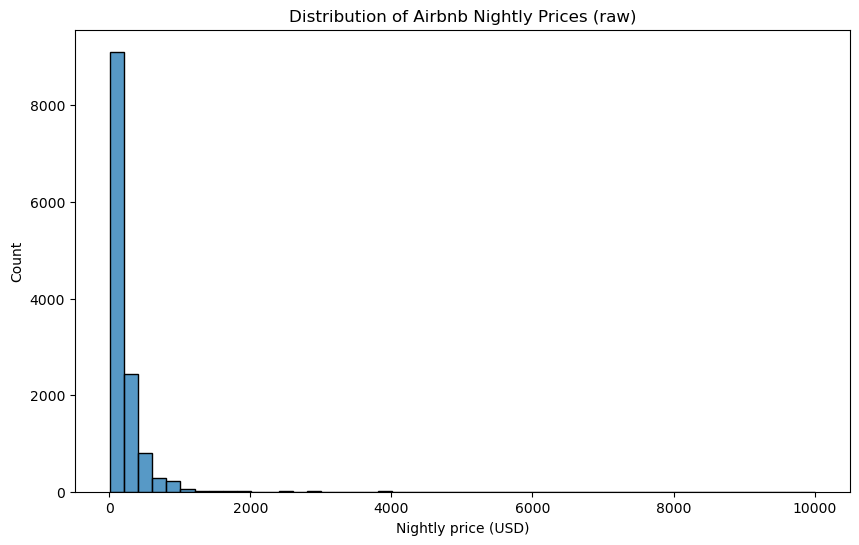

In [5]:
plt.figure(figsize=(10,6))
sns.histplot(df['nightly_price'], bins=50, kde=False)
plt.title("Distribution of Airbnb Nightly Prices (raw)")
plt.xlabel("Nightly price (USD)")
plt.ylabel("Count")
plt.show()

#### Remove Extreme Outliers

99th percentile upper bound for nightly_price: 1216.8400000000074
Dataset shape after outlier removal: (12918, 76)


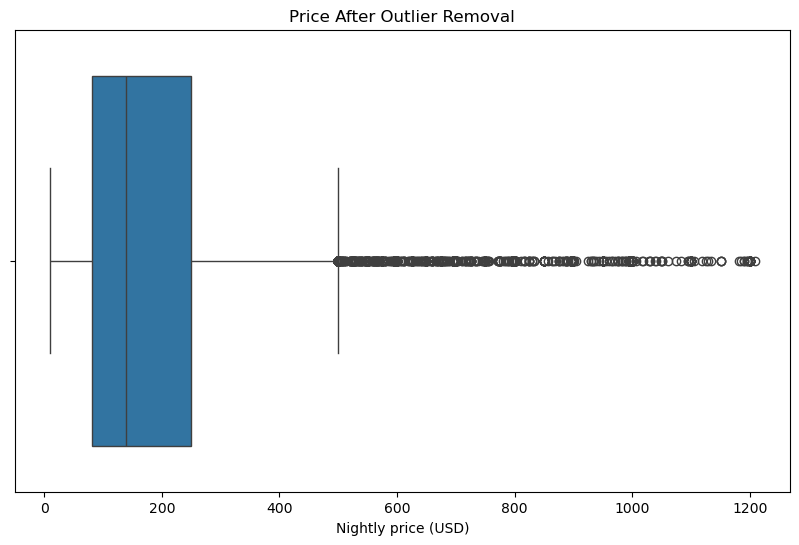

In [6]:
# Using 99th percentile to remove extreme right-tail outliers
upper_bound = df['nightly_price'].quantile(0.99)
df = df[df['nightly_price'] <= upper_bound]
print("99th percentile upper bound for nightly_price:", upper_bound)
print("Dataset shape after outlier removal:", df.shape)

# Boxplot after outlier removal
plt.figure(figsize=(10,6))
sns.boxplot(x=df['nightly_price'])
plt.title("Price After Outlier Removal")
plt.xlabel("Nightly price (USD)")
plt.show()

#### Keep Relevant Columns

In [7]:
cols_keep = [
    'room_type', 'neighbourhood', 'latitude', 'longitude',
    'minimum_nights', 'number_of_reviews', 'last_review', 'nightly_price'
]
df = df[cols_keep].copy()
print("Columns kept for analysis:", df.columns.tolist())
print("Final dataset shape:", df.shape)

Columns kept for analysis: ['room_type', 'neighbourhood', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'last_review', 'nightly_price']
Final dataset shape: (12918, 8)


#### Save Cleaned Dataset

In [8]:
os.makedirs("data/02-processed", exist_ok=True)
df.to_csv("data/02-processed/listings_clean.csv", index=False)
print("Processed dataset saved to data/02-processed/listings_clean.csv")

Processed dataset saved to data/02-processed/listings_clean.csv


#### Dataset #2: American Community Survey (ACS) Income (San Diego County)

This dataset comes from the U.S. Census Bureau’s American Community Survey (ACS), Table S1901: *Income in the Past 12 Months*. We extract the **median household income** for San Diego County, California.


**Source:** `data/00-raw/ACSST1Y2024.S1901-2026-02-19T053324.csv`

**Geographic level:** County (San Diego County, CA)  

**Variable used:** Median household income (USD) 

**Extraction logic:** Value from the row `“Median income (dollars)”` under the column corresponding to `San Diego County, California – Households!!Estimate`

This dataset provides county-level socioeconomic context for Airbnb listings in San Diego. The median household income serves as a macroeconomic benchmark for understanding the broader economic environment in which short-term rentals operate.

Because this variable is measured at the county level, it is not merged at the listing or ZIP-code level in this checkpoint. Instead, it is used to contextualize findings from the listing-level analysis.

**Limitations:**  
ACS estimates are survey-based and subject to sampling variability. County-level measures are coarse and do not capture within-county neighborhood variation.

#### Load and Inspect ACS Data

In [9]:
import pandas as pd
import os

census_file = "data/00-raw/ACSST1Y2024.S1901-2026-02-19T053324.xls"

# Check if file exists
if not os.path.exists(census_file):
    raise FileNotFoundError(f"File not found: {census_file}")

# Load CSV
census_raw = pd.read_csv(census_file, low_memory=False)

# Overview
print("ACS raw dataset shape:", census_raw.shape)
print("\nColumns:", census_raw.columns.tolist())
print("\nFirst 5 rows:")
print(census_raw.head())

ACS raw dataset shape: (17, 9)

Columns: ['Label (Grouping)', 'San Diego County, California!!Households!!Estimate', 'San Diego County, California!!Households!!Margin of Error', 'San Diego County, California!!Families!!Estimate', 'San Diego County, California!!Families!!Margin of Error', 'San Diego County, California!!Married-couple families!!Estimate', 'San Diego County, California!!Married-couple families!!Margin of Error', 'San Diego County, California!!Nonfamily households!!Estimate', 'San Diego County, California!!Nonfamily households!!Margin of Error']

First 5 rows:
         Label (Grouping) San Diego County, California!!Households!!Estimate  \
0                   Total                                          1,185,092   
1       Less than $10,000                                               3.9%   
2      $10,000 to $14,999                                               2.1%   
3      $15,000 to $24,999                                               4.2%   
4      $25,000 to $34

#### Extract Median Household Income

In [10]:
# Filter for the row containing 'Median income (dollars)'
median_row = census_raw[census_raw['Label (Grouping)'] == 'Median income (dollars)']

# Extract the value for San Diego County, Households!!Estimate
median_income = median_row['San Diego County, California!!Households!!Estimate'].values[0]

# Convert to numeric (remove commas)
median_income = int(str(median_income).replace(',', ''))
print("Median household income in San Diego County (USD):", median_income)

Median household income in San Diego County (USD): 109132


**Outcome:** Median household income is now extracted as a numeric variable and can be used to contextualize Airbnb listing prices in San Diego.

#### Section 1: Distribution of Nightly Prices

We begin by examining the distribution of Airbnb nightly prices after data cleaning and outlier removal. Prices in the short-term rental market are typically right-skewed, so understanding the distribution is important before modeling.

**Objectives:**

- Compare central tendency (mean vs. median)

- Assess degree of right skewness

- Identify remaining high-value listings

- Understand the overall spread of prices

Columns: ['room_type', 'neighbourhood', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'last_review', 'nightly_price']
Nightly price summary:
count    12918.000000
mean       200.620220
std        188.465536
min         10.000000
25%         82.000000
50%        139.000000
75%        249.000000
max       1208.000000
Name: nightly_price, dtype: float64
Median nightly price: 139.0


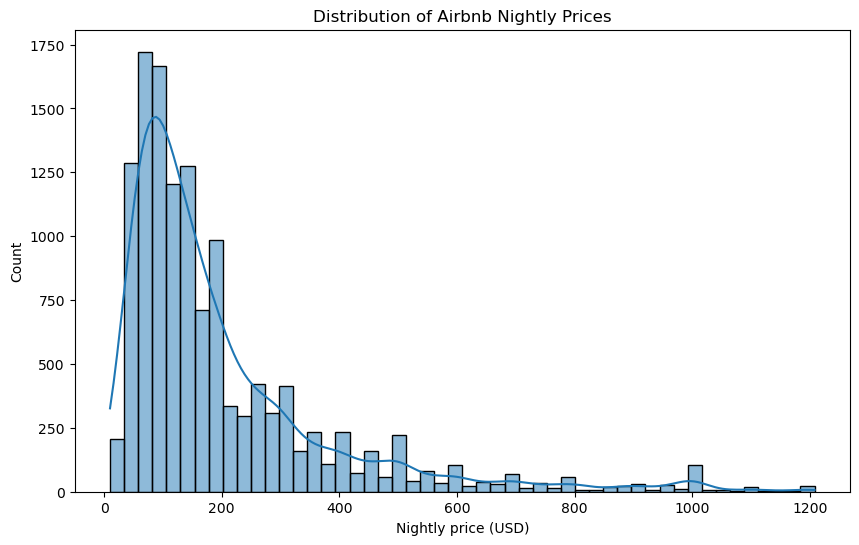

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned Airbnb dataset
df = pd.read_csv("data/02-processed/listings_clean.csv")

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("Columns:", df.columns.tolist())

# Summary statistics
print("Nightly price summary:")
print(df['nightly_price'].describe())
print("Median nightly price:", df['nightly_price'].median())

# Plot distribution
plt.figure(figsize=(10,6))
sns.histplot(df['nightly_price'], bins=50, kde=True)
plt.title("Distribution of Airbnb Nightly Prices")
plt.xlabel("Nightly price (USD)")
plt.ylabel("Count")
plt.show()

#### Section 2: Relationship Between Price and Property Features

Next, we explore how nightly prices vary across categorical property features, focusing on room_type. These variables reflect structural differences between listings and are likely strong drivers of pricing.

**Objectives:**

- Compare median and mean prices across categories

- Examine variability within each category

- Identify property types with systematically higher prices

- Observe price dispersion within similar listing types

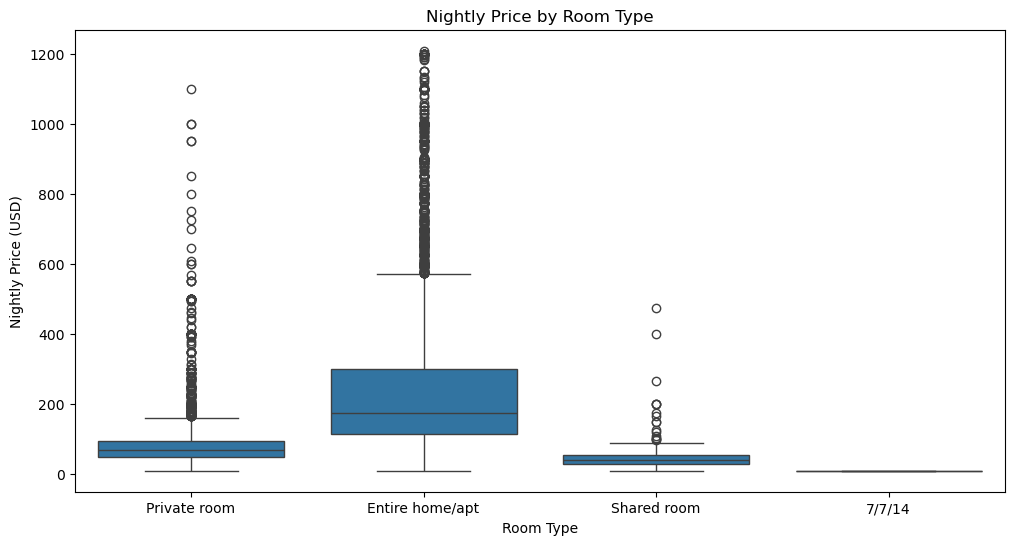

In [12]:
# Boxplot of nightly price by room type
plt.figure(figsize=(12,6))
sns.boxplot(x='room_type', y='nightly_price', data=df)
plt.title("Nightly Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Nightly Price (USD)")
plt.show()

## Results

### Exploratory Data Analysis (EDA)

We use the fully wrangled Airbnb dataset saved at `data/02-processed/listings_clean.csv` for all analysis. This avoids re-running time-consuming wrangling steps and ensures reproducibility.

**EDA Goals:**

Examine the distribution of nightly prices and room types

Explore how price relates to property features (room type, minimum nights, review counts)



### Load Cleaned Data

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
listings = pd.read_csv("data/02-processed/listings_clean.csv")

# Standardize column names
listings.columns = listings.columns.str.strip().str.lower().str.replace(' ', '_')
print("Columns:", listings.columns.tolist())
print("Dataset shape:", listings.shape)

Columns: ['room_type', 'neighbourhood', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'last_review', 'nightly_price']
Dataset shape: (12918, 8)


### Distribution of Nightly Prices

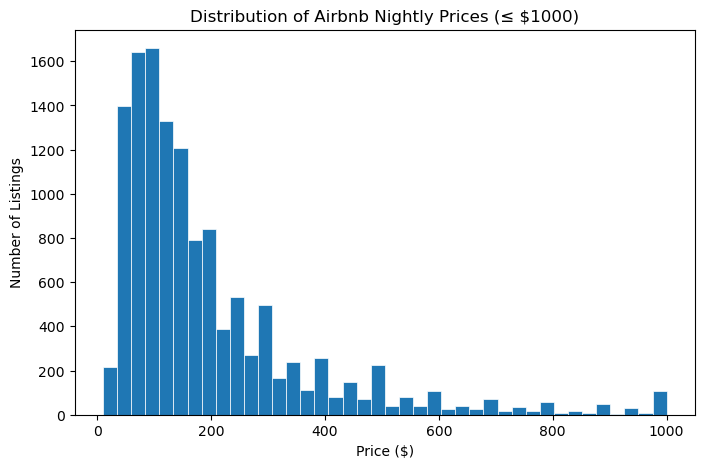

In [14]:
# Convert price to numeric and filter extreme values
listings['price_num'] = listings['nightly_price'].astype(float)
price_filtered = listings[listings['price_num'] <= 1000]

plt.figure(figsize=(8,5))
plt.hist(price_filtered['price_num'], bins=40, edgecolor='white', linewidth=0.5)
plt.title("Distribution of Airbnb Nightly Prices (≤ $1000)")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")
plt.show()

The histogram shows the distribution of Airbnb nightly prices after removing extreme outliers above $1000. 

The distribution is right-skewed, indicating that most listings are relatively affordable while only a small number have very high prices. 

Most listings fall between $50-250 per night, suggesting that the typical Airbnb price in this dataset lies within this range.

###  Distribution of Room Type

We examine the count of listings by room type to understand the composition of the market.

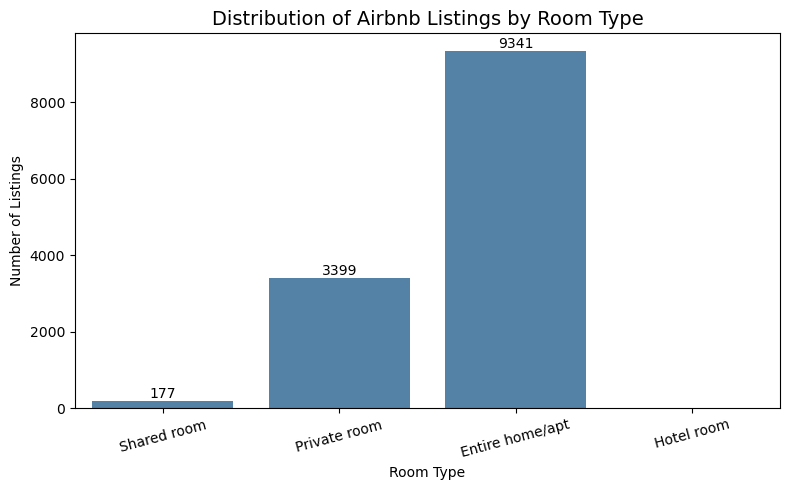

In [15]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=listings,
    x='room_type',
    order=['Shared room','Private room','Entire home/apt','Hotel room'],
    color='steelblue'
)

# Annotate counts
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Distribution of Airbnb Listings by Room Type", fontsize=14)
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Most Airbnb listings are entire homes/apartments, while shared and hotel rooms represent only a small portion of the dataset.

### Nightly Price vs. Room Type

We examine how average nightly price varies by room type.

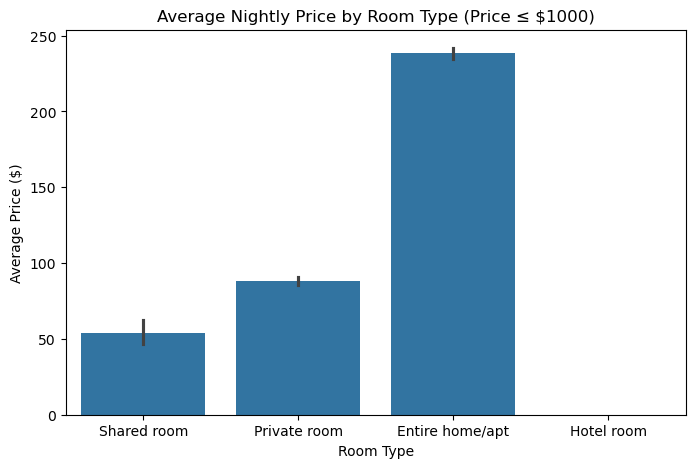

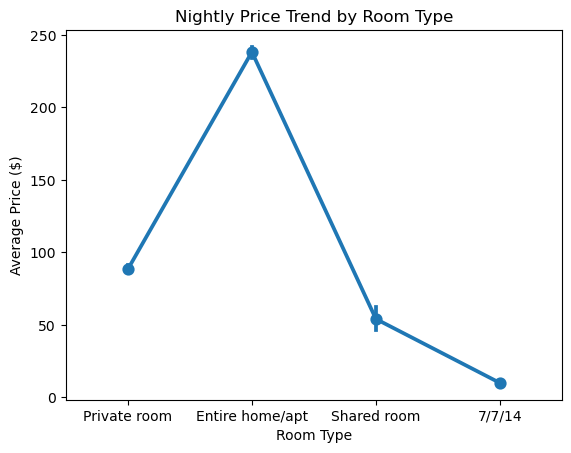

In [16]:
# Filter extreme prices again for visualization
filtered = listings[listings['price_num'] <= 1000]

plt.figure(figsize=(8,5))
sns.barplot(
    data=filtered,
    x='room_type',
    y='price_num',
    order=['Shared room','Private room','Entire home/apt','Hotel room']
)
plt.title("Average Nightly Price by Room Type (Price ≤ $1000)")
plt.xlabel("Room Type")
plt.ylabel("Average Price ($)")
plt.show()

# Point plot version
sns.pointplot(
    data=filtered,
    x='room_type',
    y='price_num'
)
plt.title("Nightly Price Trend by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price ($)")
plt.show()

- From the bar plot, we observe that hotel rooms and entire homes/apartments have the highest average prices, while private rooms are significantly cheaper and shared rooms have the lowest average price. This suggests that listings offering more space and privacy tend to be more expensive.

- The point plot shows the same trend using a connected line to highlight the differences between room types. The clear upward trend from shared rooms to hotel rooms indicates that price generally increases as the level of privacy and accommodation quality improves.


###  Nightly Price vs Minimum Nights

We examine whether minimum stay requirements relate to nightly price.

/tmp/ipykernel_5989/894931955.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['minimum_nights'] = pd.to_numeric(filtered['minimum_nights'], errors='coerce')


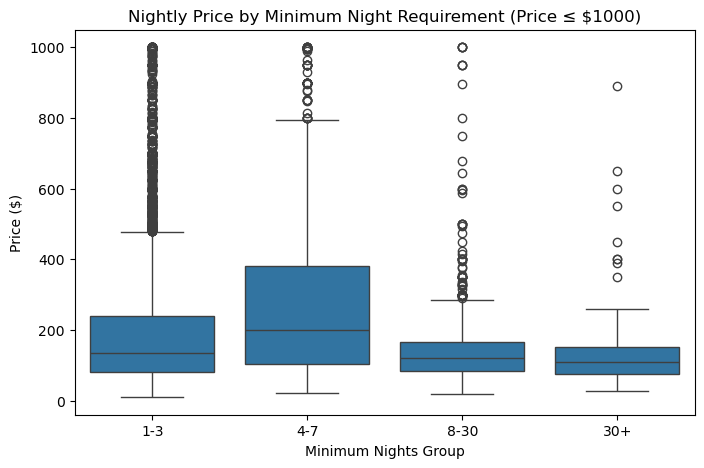

In [17]:
filtered['minimum_nights'] = pd.to_numeric(filtered['minimum_nights'], errors='coerce')

# Optional: drop rows with missing minimum_nights
filtered = filtered.dropna(subset=['minimum_nights'])

# Create minimum nights groups
filtered['night_group'] = pd.cut(
    filtered['minimum_nights'],
    bins=[0, 3, 7, 30, 365],
    labels=['1-3', '4-7', '8-30', '30+']
)

# Plot
plt.figure(figsize=(8,5))
sns.boxplot(
    x='night_group',
    y='price_num',  # make sure this column is numeric too
    data=filtered
)
plt.title("Nightly Price by Minimum Night Requirement (Price ≤ $1000)")
plt.xlabel("Minimum Nights Group")
plt.ylabel("Price ($)")
plt.show()

This boxplot shows the distribution of nightly Airbnb prices across different minimum night requirement groups. Listings with a minimum stay of 4–7 nights tend to have slightly higher median prices, while listings requiring longer stays (8–30 or 30+ nights) generally show somewhat lower prices. Overall, the differences across groups are not very large, suggesting that minimum night requirements have only a moderate effect on nightly price.

###  Price Vs Number of Reviews

We examine how the number of reviews relates to price.

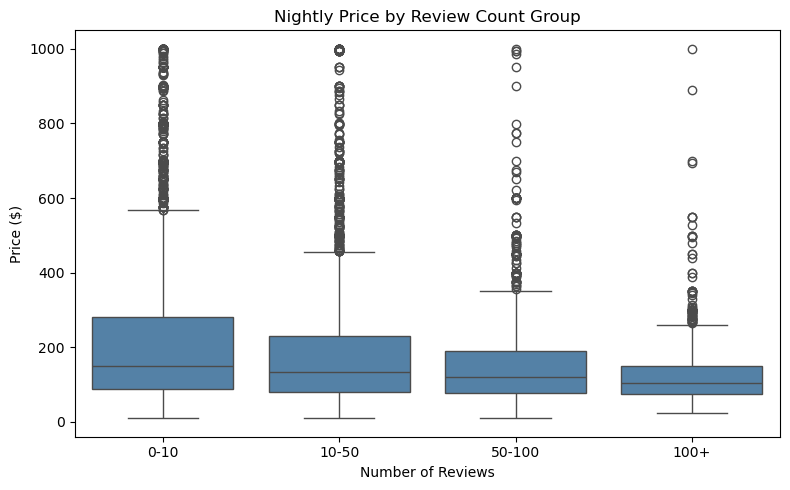

In [18]:
# Create review count groups
filtered['review_group'] = pd.cut(
    filtered['number_of_reviews'],
    bins=[0,10,50,100,2000],
    labels=['0-10','10-50','50-100','100+']
)

plt.figure(figsize=(8,5))
sns.boxplot(
    x='review_group',
    y='price_num',
    data=filtered,
    color='steelblue'
)
plt.title("Nightly Price by Review Count Group")
plt.xlabel("Number of Reviews")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.show()

Listings with many reviews may reflect more established or competitively priced listings, which could explain the slightly narrower price distribution.

## Ethics


Our ethics discussion from the proposal stage remains relevant, and we extend it here with observations grounded in the actual data we have wrangled and explored.

### Data collection and representation bias

The Inside Airbnb dataset captures only listings that were *active and publicly visible* on Airbnb at the time of scraping. This creates a systematic **survivorship bias**: listings that have been deactivated, suspended, or voluntarily removed are not present in our data. Hosts who have exited the platform — potentially due to low demand, poor reviews, or local regulation — are invisible to our analysis. Our findings therefore describe the characteristics of *currently active* listings, not the full universe of San Diego short-term rentals.

Additionally, the geographic distribution of listings in our dataset is uneven. Coastal neighborhoods (La Jolla, Pacific Beach, Mission Beach, Coronado) are heavily represented, while inland and lower-income neighborhoods have comparatively fewer listings. This means our model's performance and interpretations may generalize less well to underrepresented areas of the city.

### Neighbourhood as a proxy variable

One of our core predictors — neighbourhood or ZIP code — is a geographic variable that, in the context of San Diego, carries substantial demographic and socioeconomic meaning. Neighbourhoods in San Diego correlate with race and income due to historical patterns of residential segregation and redlining. When our model uses neighbourhood as a predictor of price, it is not capturing "location" in a purely physical sense; it is also encoding information about the social composition of the area.

We do not claim that our model discriminates by race or income — we have no such variables in our dataset. But we acknowledge that neighbourhood-based price predictions could, in practice, function as proxies for protected attributes. Any downstream use of our model (e.g., to guide pricing decisions) should account for this limitation explicitly.

### Review score bias

Our EDA includes review scores as a predictor variable. Review scores are generated only by guests who have booked and chosen to leave a review, which is a non-random subset of all guests. Guests who had very negative experiences may be less likely to write a review (preferring to simply not return), or conversely, more likely to write a negative one. This uncertainty means that review scores are not a neutral measure of quality — they reflect the opinions of a self-selected subset of guests, mediated by price expectations.

### Platform-level bias

Airbnb's search algorithm, pricing suggestions, and promotional features are not neutral. Listings that appear higher in search results may command higher prices not because of their intrinsic characteristics, but because of platform-mediated visibility advantages. Our dataset does not include information about listing visibility or algorithmic promotion, so we cannot account for this source of variation. Our findings should be understood as describing associations within the platform-visible listing pool, not as capturing the full causal structure of Airbnb pricing.

### Honest representation and scope of conclusions

Throughout our EDA and modeling, we commit to representing our findings honestly. Specifically:

- We do not make causal claims. All associations reported are correlational, derived from observational cross-sectional data.
- We acknowledge that our cleaned dataset excludes extreme outliers, which means our model may not generalize well to very high-end luxury listings or unusually cheap listings.
- We use median rather than mean prices where distributions are skewed, to avoid misleading readers about typical price levels.
- Our results describe pricing patterns on the Airbnb platform in San Diego as of the data collection date. They do not represent the full short-term or long-term rental market.
```



## Team Expectations 

The team expectations established in the proposal remain in effect with specific enhancements to support our workflow-based (rather than module-based) EDA approach.

Communication: Our primary mode of communication remains WeChat for daily updates and Zoom/In-person for weekly syncs. We expect all members to respond within 24 hours. During the EDA phase, "tagging" the next person in the workflow (e.g., Qifeng tagging Alina once data is cleaned) is required to maintain momentum.

Tone & Culture: We continue our "blunt but polite" feedback loop. Given that one person's analysis (e.g., visualization) will now be interpreted by another (e.g., narrative), we commit to open dialogue regarding how data is presented to ensure the "story" told in the text accurately reflects the "data" shown in the plots.

Decision Making: Major project decisions (e.g., dropping a variable, changing a model) require a majority vote. For EDA, the Project Lead (Jing) has final say on the overall narrative structure to ensure rubric alignment.

Task Assignment & Accountability: Tasks are assigned by EDA workflow stages (Wrangling -> Visualization -> Statistical Analysis -> Interpretation) and tracked via GitHub Issues. We have transitioned to this model to prevent unequal workload and ensure "Excellent" ratings for team participation. If a member cannot meet a deadline, they must notify the group 48 hours in advance.

Collaboration Structure (New): We explicitly agree that "the person who codes is not the sole person who writes." For every EDA section, the lead analyst must sync with the interpretation lead (Alina) to ensure the narrative provides the depth required by the COGS 108 rubric.

Conflict Resolution: We assume positive intent and use private "neutral ground" discussions for conflicts. Consistent failure to meet expectations will lead to written notice and, if unresolved after one week, contact with the instructor.

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them
| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| week2-Jan15  |  1 PM | Everyone:Read & Think about COGS 108 expectations; brainstorm topics/questions <br> Jing: Draft initial project topic and research question.| Determine best form of communication; Discuss and decide on final project topic; discuss hypothesis; begin background research | 
| week3-Jan22  |  10 AM |  Everyone: Do background research on topic <br>Jing: Draft Background & Prior Work (2-3 paragraphs). <br>Qifeng: Describe ideal Data (variables like price, location, room type). <br>Alina: Draft Ethics & Privacy + Team Expectations. | Discuss ideal dataset(s) and ethics; draft project proposal; Assign group members to lead each specific part | 
| week5-Feb3  | 10 PM  | Everyone: Edit, finalize, Final proofreading and submit proposal; Search for datasets<br>Yuqian: Write Analysis Plan (Regression/EDA focus).<br>Jing: Merge all sections into the final notebook; Check against rubric. | Submit Proposal. Discuss specific data acquisition strategy for San Diego Airbnb (Inside Airbnb/Kaggle). Wrangling and possible analytical approaches;   |
| week6-Feb11  | 6 PM  | Qifeng: Download and document the SD Airbnb dataset.<br>Ivy: Perform initial Data Cleaning (handling missing prices, filtering SD coordinates).<br>Yuqian: Preliminary EDA on price distribution. | Review Wrangling/EDA: Discuss if we need more features (e.g., amenities, proximity to coast) to test the hypothesis.   |
| week7-Feb18  | 12 PM  | Ivy: Finalize EDA visualizations (Price vs. Location heatmaps).<br>Yuqian: Run initial Regression Models (Price ~ Distance to coast + Room type).<br>Jing: Draft Checkpoint #1 documentation.; submit Checkpoint #1: Data* | Submit Checkpoint #1. Discuss if the model results support the hypothesis that scenic areas = higher prices. |
| week8-Feb28  | 2 PM | Alina: Prepare draft for data bias & ethics interpretation. <br>Yuqian: Complete bivariate analysis (Price vs. Features). | Alina & Yuqian Meeting: Discuss EDA logic flow; align statistical findings with contextual interpretation; identify any bias in the processed data. |
| week9-Mar3  | 12 PM  | Yuqian: Finalize Modeling & Interpretation of results.<br>Alina: Write Discussion (limitations of observational data) & Conclusion.<br>Ivy: Optimize all charts for clarity.<br>Jing: Compile the full project notebook.| Full Project Review: Edit the narrative flow; Ensure ethics/limitations are thoroughly addressed. Submit Checkpoint #2. |
| week10-Mar11  | Before 11:59 PM  | Alina: Finalize Video script & narration coordination.<br>Jing: Final check on all rubric requirements and formatting.<br>Everyone: Complete peer evaluation surveys. | Final Submission: Turn in the Final Project, Video, and Group Surveys. |